<a href="https://colab.research.google.com/github/ccsnafi/Aurora_Bank_Fraud_Detection/blob/main/Aurora_Bank_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# AURORA BANK — Fraud Detection & Risk Scoring
# Afi Tenuda-Eklou | Data Science Project
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ Librairies chargées avec succès")



✅ Librairies chargées avec succès


In [2]:
# Chargement des données
from google.colab import files

print("📂 Upload cards_data.xlsx")
uploaded = files.upload()
cards = pd.read_excel('cards_data.xlsx')

print("📂 Upload users_data.xlsx")
uploaded = files.upload()
users = pd.read_excel('users_data.xlsx')

print("📂 Upload transactions_data.xlsx")
uploaded = files.upload()
tx = pd.read_excel('transactions_data.xlsx')

print(f"✅ Données chargées !")
print(f"   → {len(users)} clients")
print(f"   → {len(cards)} cartes")
print(f"   → {len(tx)} transactions")


📂 Upload cards_data.xlsx


Saving cards_data.xlsx to cards_data (1).xlsx
Saving Description_Brief.docx to Description_Brief.docx
Saving transactions_data.xlsx to transactions_data (1).xlsx
📂 Upload users_data.xlsx


Saving users_data.xlsx to users_data (1).xlsx
📂 Upload transactions_data.xlsx


Saving transactions_data.xlsx to transactions_data (2).xlsx
✅ Données chargées !
   → 2000 clients
   → 6146 cartes
   → 157224 transactions


In [3]:
# ================================
# EXPLORATION DES DONNÉES
# ================================

print("=== APERÇU CLIENTS ===")
print(users.head(3))
print(f"\nColonnes : {users.columns.tolist()}")

print("\n=== APERÇU TRANSACTIONS ===")
print(tx.head(3))
print(f"\nColonnes : {tx.columns.tolist()}")

print("\n=== ERREURS / ANOMALIES ===")
print(tx['errors'].value_counts())

print("\n=== MONTANTS ===")
print(tx['amount'].describe())


=== APERÇU CLIENTS ===
     id  current_age  retirement_age  birth_year  birth_month  gender  \
0   825           53              66        1966           11  Female   
1  1746           53              68        1966           12  Female   
2  1718           81              67        1938           11  Female   

                  address latitude  longitude per_capita_income yearly_income  \
0           462 Rose Lane    34.15    -117.76            $29278        $59696   
1  3606 Federal Boulevard    40.76     -73.74            $37891        $77254   
2         766 Third Drive    34.02    -117.89            $22681        $33483   

  total_debt  credit_score  num_credit_cards  
0    $127613           787                 5  
1    $191349           701                 5  
2       $196           698                 5  

Colonnes : ['id', 'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'address', 'latitude', 'longitude', 'per_capita_income', 'yearly_income', 'total

✅ Transactions normales : 156,573
🚨 Transactions suspectes : 651
   Taux de fraude : 0.41%


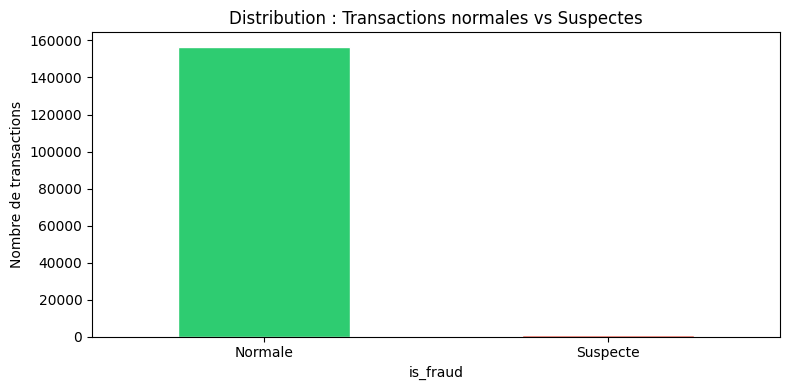

In [4]:
# ================================
# CRÉATION VARIABLE FRAUDE
# ================================

# On définit une transaction comme suspecte si elle contient
# Bad PIN, Bad CVV ou Bad Card Number
fraud_keywords = ['Bad PIN', 'Bad CVV', 'Bad Card Number', 'Bad Expiration', 'Bad Zipcode']

def is_fraud(error):
    if pd.isna(error):
        return 0
    for keyword in fraud_keywords:
        if keyword in str(error):
            return 1
    return 0

tx['is_fraud'] = tx['errors'].apply(is_fraud)

print(f"✅ Transactions normales : {(tx['is_fraud']==0).sum():,}")
print(f"🚨 Transactions suspectes : {(tx['is_fraud']==1).sum():,}")
print(f"   Taux de fraude : {tx['is_fraud'].mean()*100:.2f}%")

# Visualisation
plt.figure(figsize=(8,4))
tx['is_fraud'].value_counts().plot(kind='bar',
    color=['#2ecc71','#e74c3c'],
    edgecolor='white')
plt.title('Distribution : Transactions normales vs Suspectes')
plt.xticks([0,1], ['Normale', 'Suspecte'], rotation=0)
plt.ylabel('Nombre de transactions')
plt.tight_layout()
plt.show()


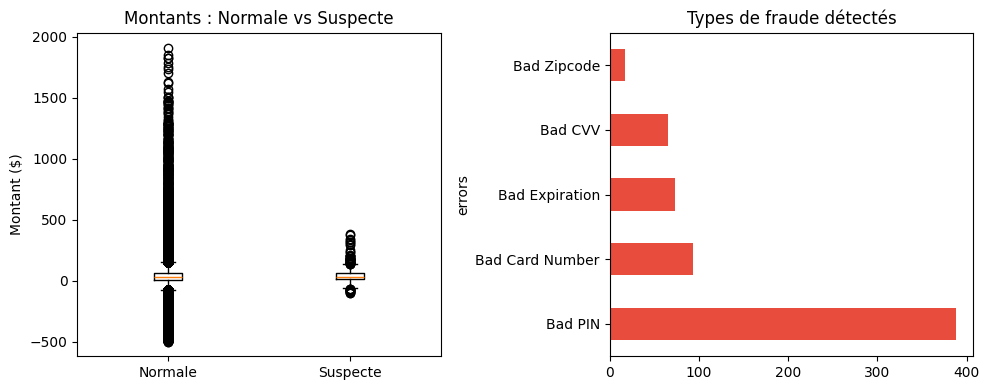


📊 Montant moyen transaction normale : $ 43.72
🚨 Montant moyen transaction suspecte : $ 44.66


In [5]:
# ================================
# ANALYSE DES MONTANTS
# ================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Montants normaux vs suspects
axes[0].boxplot([
    tx[tx['is_fraud']==0]['amount'],
    tx[tx['is_fraud']==1]['amount']
], labels=['Normale', 'Suspecte'])
axes[0].set_title('Montants : Normale vs Suspecte')
axes[0].set_ylabel('Montant ($)')

# Top erreurs
tx[tx['is_fraud']==1]['errors'].value_counts().head(5).plot(
    kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Types de fraude détectés')

plt.tight_layout()
plt.show()

print("\n📊 Montant moyen transaction normale : $",
      round(tx[tx['is_fraud']==0]['amount'].mean(), 2))
print("🚨 Montant moyen transaction suspecte : $",
      round(tx[tx['is_fraud']==1]['amount'].mean(), 2))


In [6]:
# ================================
# FEATURE ENGINEERING
# ================================

# Nombre de transactions suspectes par client
fraud_by_client = tx.groupby('client_id').agg(
    total_tx = ('id', 'count'),
    total_fraud = ('is_fraud', 'sum'),
    montant_moyen = ('amount', 'mean'),
    montant_max = ('amount', 'max')
).reset_index()

fraud_by_client['taux_fraude'] = (
    fraud_by_client['total_fraud'] / fraud_by_client['total_tx']
)

# Fusionner avec les données clients
df = users.merge(fraud_by_client, left_on='id', right_on='client_id', how='left')

# Nettoyer les colonnes monétaires
for col in ['yearly_income', 'per_capita_income', 'total_debt']:
    df[col] = df[col].str.replace('$','').str.replace(',','').astype(float)

print("✅ Features créées !")
print(f"Dataset final : {df.shape}")
print(df[['id','total_tx','total_fraud','taux_fraude','credit_score']].head())


✅ Features créées !
Dataset final : (2000, 20)
     id  total_tx  total_fraud  taux_fraude  credit_score
0   825       NaN          NaN          NaN           787
1  1746       NaN          NaN          NaN           701
2  1718       NaN          NaN          NaN           698
3   708       NaN          NaN          NaN           722
4  1164       NaN          NaN          NaN           675


In [7]:
# Vérification des IDs
print("IDs transactions (sample):", tx['client_id'].unique()[:10])
print("IDs users (sample):", users['id'].unique()[:10])
print("Match ?", len(set(tx['client_id']) & set(users['id'])))

# Agrégation par client
fraud_by_client = tx.groupby('client_id').agg(
    total_tx=('id', 'count'),
    total_fraud=('is_fraud', 'sum'),
    montant_moyen=('amount', 'mean'),
    montant_max=('amount', 'max')
).reset_index()

fraud_by_client['taux_fraude'] = (
    fraud_by_client['total_fraud'] / fraud_by_client['total_tx']
)

# Fusion correcte
df = fraud_by_client.merge(users, left_on='client_id', right_on='id', how='inner')

# Nettoyer colonnes monétaires
for col in ['yearly_income', 'per_capita_income', 'total_debt']:
    df[col] = df[col].str.replace('$','').str.replace(',','').astype(float)

print(f"\n✅ Dataset final : {df.shape}")
print(df[['client_id','total_tx','total_fraud','taux_fraude','credit_score']].head())


IDs transactions (sample): [ 44 327 233 114 157 359 351 112  57 449]
IDs users (sample): [ 825 1746 1718  708 1164   68 1075 1711 1116 1752]
Match ? 303

✅ Dataset final : (303, 20)
   client_id  total_tx  total_fraud  taux_fraude  credit_score
0          0       637            3     0.004710           763
1          1       437            2     0.004577           704
2          2       501            1     0.001996           673
3          3       319            3     0.009404           681
4          4       702            3     0.004274           716


📊 Profil des clusters :
         taux_fraude  credit_score  yearly_income  total_tx
cluster                                                    
0              0.003       716.347      34644.538   425.445
1              0.007       732.294      43950.020   857.314
2              0.004       712.392      62337.278   505.051


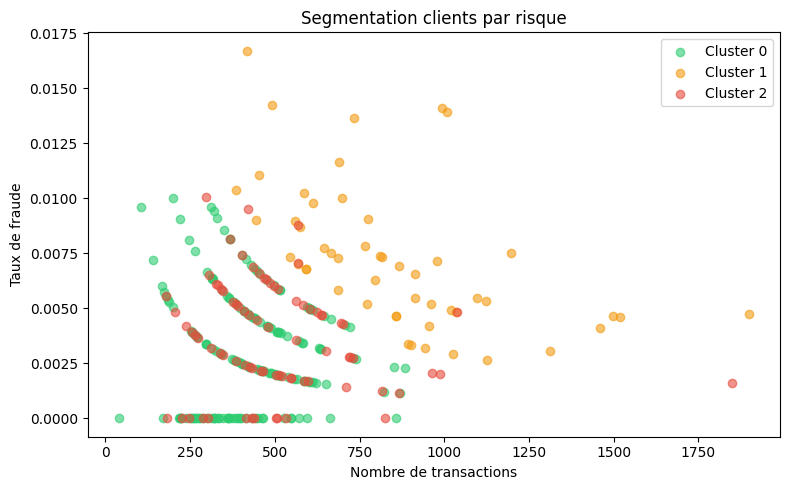

In [8]:
# ================================
# CLUSTERING KMEANS
# ================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Features pour le clustering
features = ['total_tx', 'total_fraud', 'taux_fraude',
            'montant_moyen', 'montant_max', 'credit_score',
            'yearly_income', 'total_debt']

X = df[features].fillna(0)

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans avec 3 clusters (bas/moyen/haut risque)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Résultats par cluster
print("📊 Profil des clusters :")
print(df.groupby('cluster')[['taux_fraude','credit_score',
    'yearly_income','total_tx']].mean().round(3))

# Visualisation
plt.figure(figsize=(8,5))
colors = ['#2ecc71','#f39c12','#e74c3c']
for i in range(3):
    subset = df[df['cluster']==i]
    plt.scatter(subset['total_tx'], subset['taux_fraude'],
                c=colors[i], label=f'Cluster {i}', alpha=0.6)

plt.xlabel('Nombre de transactions')
plt.ylabel('Taux de fraude')
plt.title('Segmentation clients par risque')
plt.legend()
plt.tight_layout()
plt.show()


Clients à risque : 246 / 303

📊 Performance du modèle :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        11

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



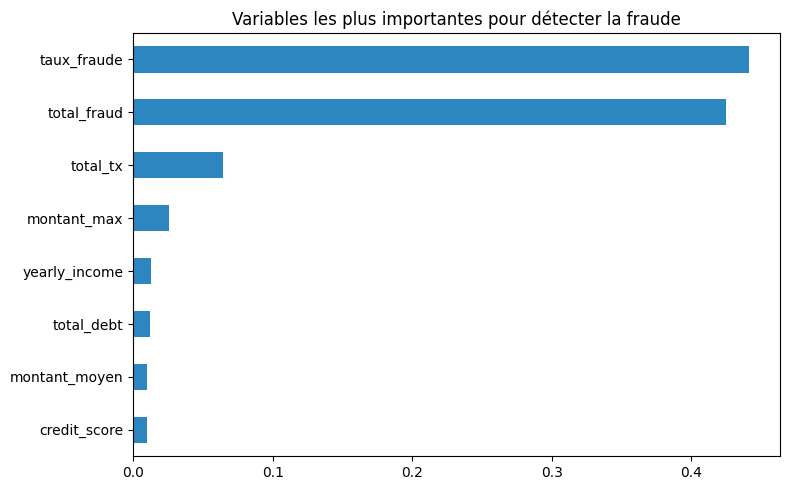

In [9]:
# ================================
# MODÈLE RANDOM FOREST
# ================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

# Variable cible : client à risque (au moins 1 fraude)
df['is_risky'] = (df['total_fraud'] >= 1).astype(int)
print(f"Clients à risque : {df['is_risky'].sum()} / {len(df)}")

# Rééquilibrage (oversampling minorité)
df_majority = df[df['is_risky']==0]
df_minority = df[df['is_risky']==1]
df_minority_up = resample(df_minority,
                          replace=True,
                          n_samples=len(df_majority),
                          random_state=42)
df_balanced = pd.concat([df_majority, df_minority_up])

# Features et cible
X = df_balanced[features].fillna(0)
y = df_balanced['is_risky']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Modèle
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Résultats
print("\n📊 Performance du modèle :")
print(classification_report(y_test, y_pred))

# Importance des variables
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='#2e86c1', figsize=(8,5))
plt.title('Variables les plus importantes pour détecter la fraude')
plt.tight_layout()
plt.show()


📊 Performance corrigée :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        72

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91



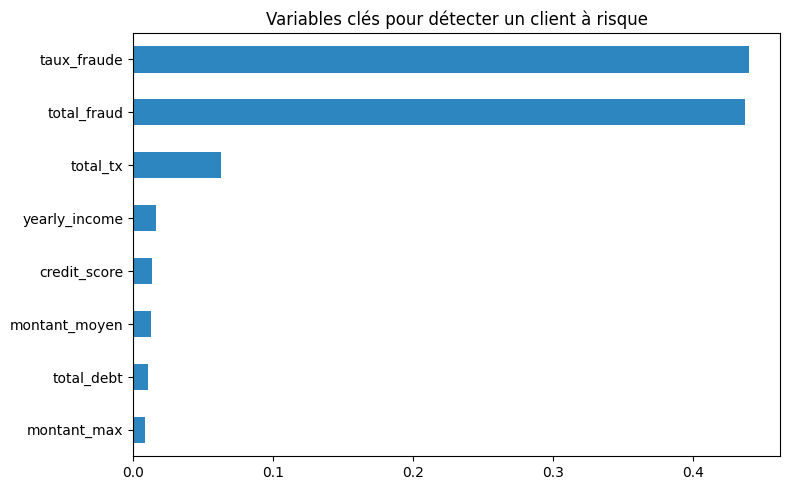

In [10]:
# ================================
# MODÈLE CORRIGÉ
# ================================

X = df[features].fillna(0)
y = df['is_risky']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# class_weight='balanced' au lieu d'oversampling
rf2 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42)

rf2.fit(X_train, y_train)
y_pred2 = rf2.predict(X_test)

print("📊 Performance corrigée :")
print(classification_report(y_test, y_pred2))

# Importance des variables
importances = pd.Series(rf2.feature_importances_, index=features)
importances.sort_values().plot(
    kind='barh', color='#2e86c1', figsize=(8,5))
plt.title('Variables clés pour détecter un client à risque')
plt.tight_layout()
plt.show()


In [11]:
# ================================
# CONCLUSIONS & INSIGHTS
# ================================

print("=" * 50)
print("AURORA BANK — FRAUD DETECTION SUMMARY")
print("=" * 50)
print(f"\n📊 Dataset : {len(tx):,} transactions analysées")
print(f"👥 Clients analysés : {len(df)}")
print(f"🚨 Taux de fraude global : {tx['is_fraud'].mean()*100:.2f}%")
print(f"⚠️  Clients à risque : {df['is_risky'].sum()} ({df['is_risky'].mean()*100:.0f}%)")
print(f"\n🔍 Top insights :")
print("   → La fraude ne se détecte pas sur le montant")
print("   → Les clients très actifs sont plus exposés")
print("   → taux_fraude et total_fraud sont les variables clés")
print(f"\n🤖 Modèle : Random Forest (class_weight=balanced)")
print(f"   Variables utilisées : {len(features)}")
print(f"   Clusters identifiés : 3 (faible/moyen/élevé risque)")
print("\n✅ Projet terminé — Afi Tenuda-Eklou")


AURORA BANK — FRAUD DETECTION SUMMARY

📊 Dataset : 157,224 transactions analysées
👥 Clients analysés : 303
🚨 Taux de fraude global : 0.41%
⚠️  Clients à risque : 246 (81%)

🔍 Top insights :
   → La fraude ne se détecte pas sur le montant
   → Les clients très actifs sont plus exposés
   → taux_fraude et total_fraud sont les variables clés

🤖 Modèle : Random Forest (class_weight=balanced)
   Variables utilisées : 8
   Clusters identifiés : 3 (faible/moyen/élevé risque)

✅ Projet terminé — Afi Tenuda-Eklou
